### <b>DECISION TREE REGRESSOR</b>

In [26]:
import pandas as pd
import numpy as np

In [27]:
df = pd.read_csv('C:\\Users\\subham\\Desktop\\DECISION-TREE\\IRIS.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [29]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [30]:
# split into x and y (predicting petal_length as continuous target)
x = df.drop('petal_length', axis=1)
y = df['petal_length']

In [31]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = x.select_dtypes(include=['object']).columns

# Encode each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le

print("Categorical columns encoded:", list(categorical_cols))
print(x.head())

Categorical columns encoded: ['species']
   sepal_length  sepal_width  petal_width  species
0           5.1          3.5          0.2        0
1           4.9          3.0          0.2        0
2           4.7          3.2          0.2        0
3           4.6          3.1          0.2        0
4           5.0          3.6          0.2        0


In [32]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


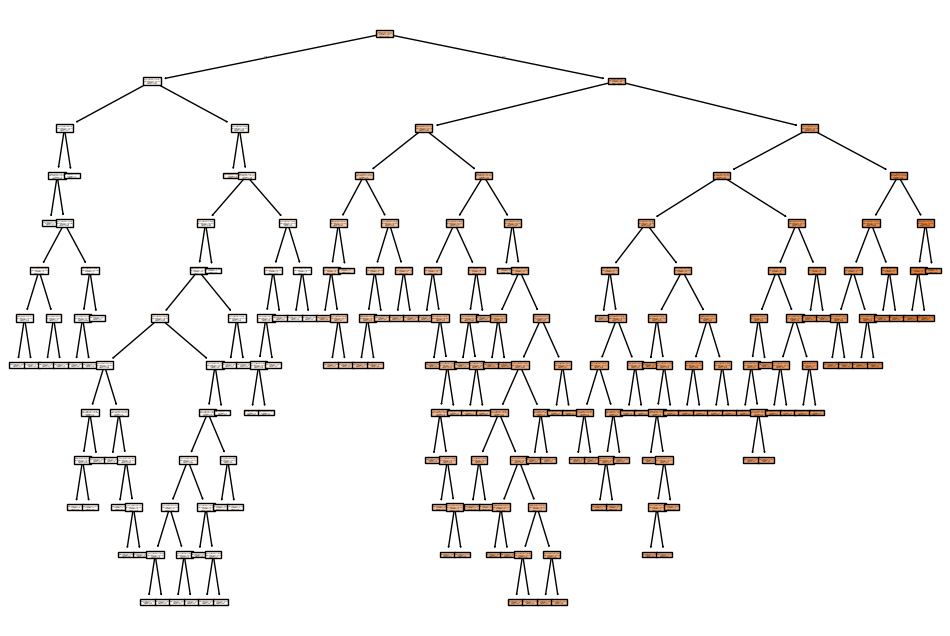

In [34]:
# Visualize the decision tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=x.columns)
plt.show()

In [35]:
y_pred = model.predict(x_test)

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")

Mean Squared Error: 0.13525000000000004
Mean Absolute Error: 0.30500000000000005
R² Score: 0.9587323919787093


In [37]:
params = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'max_depth': [1,2,3,4,5,6],
    'splitter': ['best', 'random'],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [38]:
params

{'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
 'max_depth': [1, 2, 3, 4, 5, 6],
 'splitter': ['best', 'random'],
 'max_features': ['auto', 'sqrt', 'log2']}

In [39]:
from sklearn.model_selection import GridSearchCV
treemodel = DecisionTreeRegressor()

In [40]:
grid = GridSearchCV(treemodel, param_grid=params, cv=5, scoring='r2')

In [41]:
import warnings
warnings.filterwarnings('ignore')

In [42]:
grid.fit(x_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'poisson'


In [43]:
grid.best_params_

{'criterion': 'poisson',
 'max_depth': 6,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [44]:
grid.best_score_

np.float64(0.9648239944902837)

In [45]:
y_pred = grid.predict(x_test)

In [46]:
y_pred

array([4.        , 1.2       , 6.46666667, 4.64      , 4.64      ,
       1.5       , 4.13333333, 5.55714286, 4.64      , 4.13333333,
       5.55714286, 1.45714286, 1.45      , 1.45714286, 1.45      ,
       5.8       , 5.36      , 3.75      , 4.13333333, 5.06666667,
       1.32      , 4.85      , 1.6       , 5.06666667, 6.7       ,
       5.36      , 5.06666667, 5.55714286, 1.3       , 1.45714286])

In [47]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")

Mean Squared Error: 0.1597066061980347
Mean Absolute Error: 0.3095555555555555
R² Score: 0.9512701691460915
